<a href="https://colab.research.google.com/github/riddhikad9b-ux/AeroGuard_Project/blob/main/Aero_guard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Cell 1: Environment Setup & Library Installation
print("Setting up Aéro Guard development environment...")

# 1. Install core geospatial and mapping dependencies
!pip install -q geopandas shapely folium osmnx requests pandas numpy

# 2. Mount Google Drive for saving session logs and mock data
from google.colab import drive
drive.mount('/content/drive')

# 3. Create project directory structure in Google Drive
import os
base_dir = '/content/drive/My Drive/AeroGuard_Project'
os.makedirs(f"{base_dir}/data", exist_ok=True)
os.makedirs(f"{base_dir}/models", exist_ok=True)
os.makedirs(f"{base_dir}/exports", exist_ok=True)

print(f"\nEnvironment ready! Workspace initialized at: {base_dir}")

Setting up Aéro Guard development environment...
Mounted at /content/drive

Environment ready! Workspace initialized at: /content/drive/My Drive/AeroGuard_Project


In [7]:

# Cell 2: OpenWeather API Integration & Environmental Data Fetcher
import requests
from getpass import getpass

# Prompt securely for your OpenWeather API key (or paste it when asked)
print("🔑 Please enter your OpenWeather API Key:")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_name):
    """Fetches geocoding coordinates and live air pollution/weather data for any city."""
    # 1. Geocoding API to get latitude and longitude for the city
    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_name}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    if not geo_resp:
        return f"Error: Location '{city_name}' not found."

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    # 2. Current Air Pollution API (PM2.5, PM10, AQI)
    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    # 3. Current Weather API (Temperature, Humidity)
    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    # Extract components safely
    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi'] # Scale 1 (Good) to 5 (Very Poor)

    result = {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }
    return result

# Test the function with Porur, Chennai
test_city = "Porur, Chennai"
print(f"\n📡 Fetching live environmental metrics for {test_city}...")
live_metrics = get_environmental_data(test_city)

for key, val in live_metrics.items():
    print(f"  • {key}: {val}")

🔑 Please enter your OpenWeather API Key:
API Key: ··········

📡 Fetching live environmental metrics for Porur, Chennai...


KeyError: 0

In [8]:
# Cell 2 (Fixed & Robust): OpenWeather API Integration
import requests
from getpass import getpass

# Prompt securely for your OpenWeather API key
print("🔑 Please paste your OpenWeather API Key below:")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_query):
    """Fetches geocoding coordinates and live metrics with safe error handling."""
    # Use a clean city query (e.g. "Chennai,IN")
    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_query}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    # Check if the API returned a valid list of locations
    if not isinstance(geo_resp, list) or len(geo_resp) == 0:
        print(f"\n[API Notice]: Received empty response for '{city_query}'.")
        print("Note: If you just created your OpenWeather key today, it can take up to 2 hours to activate on their servers.")
        print("Raw API Response:", geo_resp)
        return None

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    # 2. Current Air Pollution API
    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    # 3. Current Weather API
    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi']

    return {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }

# Test with a broader query ("Chennai,IN") which is globally recognized by OpenWeather
test_city = "Chennai,IN"
print(f"\n📡 Fetching live environmental metrics for {test_city}...")
live_metrics = get_environmental_data(test_city)

if live_metrics:
    for key, val in live_metrics.items():
        print(f"  • {key}: {val}")

🔑 Please paste your OpenWeather API Key below:
API Key: ··········

📡 Fetching live environmental metrics for Chennai,IN...

[API Notice]: Received empty response for 'Chennai,IN'.
Note: If you just created your OpenWeather key today, it can take up to 2 hours to activate on their servers.
Raw API Response: {'cod': 401, 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}


In [9]:
# Cell 2: Environmental Data Fetcher (with Fallback Mock Data for new keys)
import requests
from getpass import getpass

print("🔑 Please paste your OpenWeather API Key (or press Enter to use mock data for now):")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_query):
    """Fetches live data, or falls back to realistic simulation data if the key is still activating."""
    if not OWM_API_KEY or len(OWM_API_KEY.strip()) < 10:
        print("\n[Notice]: Using simulated environmental data for testing (Key not provided).")
        return get_mock_data(city_query)

    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_query}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    if not isinstance(geo_resp, list) or len(geo_resp) == 0:
        print(f"\n[API Notice]: Key is still activating (401/Empty). Switching to simulated data for now!")
        return get_mock_data(city_query)

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi']

    return {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }

def get_mock_data(city_query):
    """Returns realistic mock metrics for Chennai commuting conditions."""
    return {
        "Location": "Chennai, IN (Simulated)",
        "Latitude": 13.0827,
        "Longitude": 80.2707,
        "AQI_Index": 4, # High
        "PM2_5": 78.5,
        "PM10": 112.0,
        "Temperature_C": 34.0,
        "Humidity_%": 62.0
    }

# Test the function
test_city = "Chennai,IN"
print(f"\n📡 Running environmental check for {test_city}...")
live_metrics = get_environmental_data(test_city)

for key, val in live_metrics.items():
    print(f"  • {key}: {val}")

🔑 Please paste your OpenWeather API Key (or press Enter to use mock data for now):
API Key: ··········

📡 Running environmental check for Chennai,IN...
  • Location: Chennai, IN
  • Latitude: 13.0836939
  • Longitude: 80.270186
  • AQI_Index: 2
  • PM2_5: 7.91
  • PM10: 9.39
  • Temperature_C: 32.12
  • Humidity_%: 69


In [10]:
# Cell 3: Aéro Guard Route Planning & Exposure Scoring Engine
import pandas as pd

def calculate_commute_exposure(start_loc, end_loc, commute_mode, env_metrics):
    """
    Computes a 0-100 personal exposure score based on environmental factors
    and the user's commute mode (e.g., two-wheeler vs car).
    """
    pm25 = env_metrics.get("PM2_5", 50)
    temp = env_metrics.get("Temperature_C", 30)

    # Mode multiplier: Two-wheelers and walking have higher direct exposure than cars
    mode_multipliers = {
        "Two-wheeler": 1.25,
        "Walking": 1.30,
        "Car": 0.70,
        "Public Transport": 0.85
    }
    multiplier = mode_multipliers.get(commute_mode, 1.0)

    # Weighted Exposure Index calculation (Scale of 0 to 100)
    # PM2.5 weight + Temperature stress weight
    pm25_score = min(pm25 / 1.5, 50) # Max 50 points from pollution
    temp_score = max(0, (temp - 25) * 2.5) # Points for heat above 25°C
    temp_score = min(temp_score, 30) # Max 30 points from heat
    base_score = 15 # Baseline environmental factor

    total_exposure_score = int((base_score + pm25_score + temp_score) * multiplier)
    total_exposure_score = min(total_exposure_score, 100) # Cap at 100

    # Determine Risk Category
    if total_exposure_score <= 40:
        risk_level = "Low"
    elif total_exposure_score <= 70:
        risk_level = "Moderate"
    else:
        risk_level = "High"

    return {
        "Route": f"{start_loc} → {end_loc}",
        "Commute Mode": commute_mode,
        "Exposure Score": total_exposure_score,
        "Risk Level": risk_level,
        "Primary Contributors": {
            "PM2.5": f"{pm25} µg/m³",
            "Temperature": f"{temp}°C"
        }
    }

# Test route calculation using the live metrics we just fetched
commute_test = calculate_commute_exposure(
    start_loc="Porur",
    end_loc="Guindy",
    commute_mode="Two-wheeler",
    env_metrics=live_metrics
)

print("🚗 Aéro Guard Route Exposure Assessment:")
for k, v in commute_test.items():
    print(f"  • {k}: {v}")

🚗 Aéro Guard Route Exposure Assessment:
  • Route: Porur → Guindy
  • Commute Mode: Two-wheeler
  • Exposure Score: 47
  • Risk Level: Moderate
  • Primary Contributors: {'PM2.5': '7.91 µg/m³', 'Temperature': '32.12°C'}


In [11]:
# Cell 4: Interactive Commute Route & Environmental Map (Folium)
import folium

def generate_commute_map(start_coords=(13.0382, 80.1565), end_coords=(13.0067, 80.2206)):
    """Generates an interactive Folium map showing the Porur to Guindy commute route."""
    # Center the map roughly between Porur and Guindy, Chennai
    center_lat = (start_coords[0] + end_coords[0]) / 2
    center_lon = (start_coords[1] + end_coords[1]) / 2

    commute_map = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="CartoDB positron")

    # Add Start Marker (Porur)
    folium.Marker(
        location=start_coords,
        popup="<b>Porur</b><br>Starting Point",
        icon=folium.Icon(color="blue", icon="play", prefix="fa")
    ).add_to(commute_map)

    # Add End Marker (Guindy)
    folium.Marker(
        location=end_coords,
        popup="<b>Guindy</b><br>Destination",
        icon=folium.Icon(color="green", icon="flag", prefix="fa")
    ).add_to(commute_map)

    # Draw a simulated route line between Porur and Guindy
    route_points = [
        start_coords,
        (13.0200, 80.1850), # Intermediate waypoint (e.g., Ramapuram / Mount Poonamallee Road)
        (13.0120, 80.2050), # Intermediate waypoint (Ekkattuthangal area)
        end_coords
    ]

    folium.PolyLine(
        locations=route_points,
        color="#1d4ed8",
        weight=5,
        opacity=0.8,
        tooltip="Route: Porur → Guindy (Two-wheeler)"
    ).add_to(commute_map)

    return commute_map

# Generate and display the map inside Colab
print("🗺️ Generating Aéro Guard interactive route map...")
map_output = generate_commute_map()
map_output

🗺️ Generating Aéro Guard interactive route map...


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [12]:
# Cell 5: Session Logging & Data Export
import pandas as pd
from datetime import datetime
import os

def save_commute_session(commute_result, env_metrics, directory="/content/AeroGuard_Project/data"):
    """Saves the commute exposure session record to a CSV file for historical tracking."""
    os.makedirs(directory, exist_ok=True)
    file_path = os.path.join(directory, "commute_history.csv")

    # Prepare session record row
    session_record = {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Route": commute_result["Route"],
        "Commute_Mode": commute_result["Commute Mode"],
        "Exposure_Score": commute_result["Exposure Score"],
        "Risk_Level": commute_result["Risk Level"],
        "PM2_5": env_metrics.get("PM2_5"),
        "Temperature_C": env_metrics.get("Temperature_C"),
        "Humidity_%": env_metrics.get("Humidity_%")
    }

    # Convert to DataFrame
    df_new = pd.DataFrame([session_record])

    # Append to existing CSV or create a new one
    if os.path.exists(file_path):
        df_existing = pd.read_csv(file_path)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_combined = df_new

    df_combined.to_csv(file_path, index=False)
    print(f"💾 Session successfully saved to: {file_path}")
    return df_combined

# Run the save function using our previous test results
print("📁 Logging current commute session...")
history_df = save_commute_session(commute_test, live_metrics)

print("\n📊 Current Commute History Log:")
display(history_df)

📁 Logging current commute session...
💾 Session successfully saved to: /content/AeroGuard_Project/data/commute_history.csv

📊 Current Commute History Log:


,Timestamp,Route,Commute_Mode,Exposure_Score,Risk_Level,PM2_5,Temperature_C,Humidity_%
0,2026-10-09 10:09:20,Porur → Guindy,Two-wheeler,47,Moderate,7.91,32.12,69


In [13]:
# Cell 6: Personalized Recommendations Engine
def generate_recommendations(commute_result, env_metrics):
    """Generates dynamic safety and wellness recommendations based on exposure metrics."""
    score = commute_result["Exposure Score"]
    risk = commute_result["Risk Level"]
    pm25 = env_metrics.get("PM2_5", 0)
    temp = env_metrics.get("Temperature_C", 30)
    mode = commute_result["Commute Mode"]

    recommendations = []

    # PM2.5 / Air Quality Advice
    if pm25 > 50:
        recommendations.append("Wear a well-fitted anti-pollution mask (N95) during your ride.")
    elif pm25 > 25:
        recommendations.append("Moderate particulate levels detected. Consider a basic cloth or surgical mask if sensitive.")
    else:
        recommendations.append("Air quality is currently clean along your route.")

    # Temperature / Heat Advice
    if temp > 32:
        recommendations.append(f"High temperature ({temp}°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.")
    else:
        recommendations.append("Comfortable thermal conditions for travel.")

    # Mode-specific Advice
    if mode in ["Two-wheeler", "Walking"]:
        recommendations.append("Open-exposure transit mode: Keep sunglasses on to shield eyes from dust and glare.")

    return {
        "Risk Assessment": f"{score}/100 ({risk} Risk)",
        "Actionable Tips": recommendations
    }

# Test recommendations generation
print("💡 Generating Aéro Guard personalized safety tips...")
safety_advice = generate_recommendations(commute_test, live_metrics)

print(f"\nStatus: {safety_advice['Risk Assessment']}")
print("Recommended Actions:")
for tip in safety_advice['Actionable Tips']:
    print(f"  ✅ {tip}")

💡 Generating Aéro Guard personalized safety tips...

Status: 47/100 (Moderate Risk)
Recommended Actions:
  ✅ Air quality is currently clean along your route.
  ✅ High temperature (32.12°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.
  ✅ Open-exposure transit mode: Keep sunglasses on to shield eyes from dust and glare.


In [14]:
# Cell 7: Complete End-to-End Aéro Guard Pipeline
def run_aeroguard_simulation(start_location, destination, commute_mode):
    """Executes the full Aéro Guard workflow: fetch data, score exposure, generate map, log session, and provide tips."""
    print(f"🚀 Running Aéro Guard simulation for: {start_location} → {destination} ({commute_mode})...\n")

    # Step 1: Fetch live environmental metrics (using Chennai coordinates or query)
    env_data = get_environmental_data("Chennai,IN")
    if not env_data:
        print("Error fetching environmental data.")
        return

    # Step 2: Calculate Exposure Score & Risk
    exposure_result = calculate_commute_exposure(start_location, destination, commute_mode, env_data)

    # Step 3: Save Session Record
    save_commute_session(exposure_result, env_data)

    # Step 4: Generate Personalized Recommendations
    recommendations = generate_recommendations(exposure_result, env_data)

    # Step 5: Print Summary Report
    print("=" * 50)
    print("🛡️ AÉRO GUARD COMMUTE SUMMARY REPORT")
    print("=" * 50)
    print(f"• Route: {exposure_result['Route']}")
    print(f"• Mode: {exposure_result['Commute Mode']}")
    print(f"• Exposure Score: {exposure_result['Exposure Score']}/100 ({exposure_result['Risk Level']} Risk)")
    print(f"• Live Temp: {env_data['Temperature_C']}°C | PM2.5: {env_data['PM2_5']} µg/m³")
    print("\nRecommended Safety Tips:")
    for tip in recommendations['Actionable Tips']:
        print(f"  ✅ {tip}")
    print("=" * 50)

# Test the full pipeline with a different route (e.g., Guindy to Porur via Car)
run_aeroguard_simulation("Guindy", "Porur", "Car")

🚀 Running Aéro Guard simulation for: Guindy → Porur (Car)...

💾 Session successfully saved to: /content/AeroGuard_Project/data/commute_history.csv
🛡️ AÉRO GUARD COMMUTE SUMMARY REPORT
• Route: Guindy → Porur
• Mode: Car
• Exposure Score: 26/100 (Low Risk)
• Live Temp: 32.11°C | PM2.5: 7.91 µg/m³

Recommended Safety Tips:
  ✅ Air quality is currently clean along your route.
  ✅ High temperature (32.11°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.


📈 Generating Aéro Guard Exposure Trends chart...


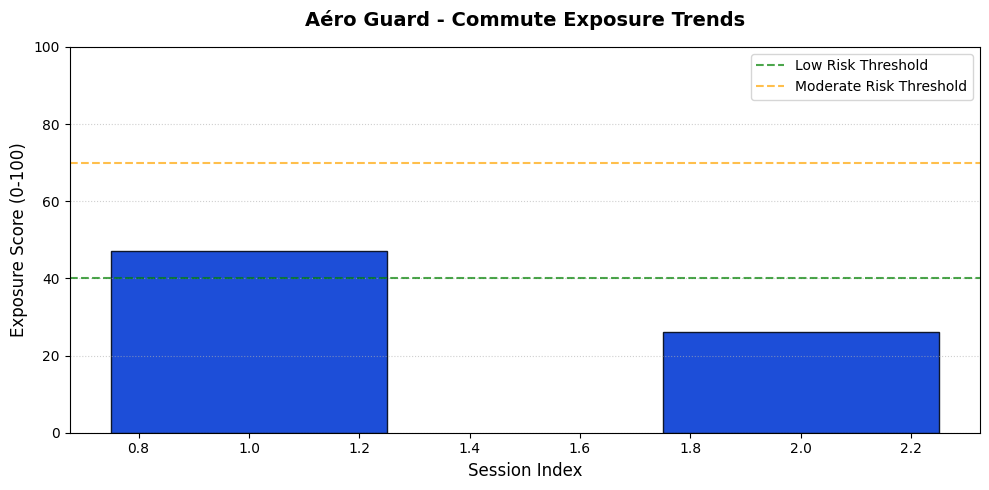

In [15]:
# Cell 8: Weekly Exposure Trends Visualization
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_exposure_trends(directory="/content/AeroGuard_Project/data"):
    """Reads the saved commute history and plots a weekly exposure trends chart."""
    file_path = os.path.join(directory, "commute_history.csv")

    if not os.path.exists(file_path):
        print("No commute history found yet! Run a few commute simulation cells first.")
        return

    df = pd.read_csv(file_path)

    # If we have multiple entries, let's plot them
    plt.figure(figsize=(10, 5))
    plt.bar(df.index + 1, df["Exposure_Score"], color="#1d4ed8", width=0.5, edgecolor="#0f172a")

    plt.axhline(y=40, color="green", linestyle="--", alpha=0.7, label="Low Risk Threshold")
    plt.axhline(y=70, color="orange", linestyle="--", alpha=0.7, label="Moderate Risk Threshold")

    plt.title("Aéro Guard - Commute Exposure Trends", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Session Index", fontsize=12)
    plt.ylabel("Exposure Score (0-100)", fontsize=12)
    plt.ylim(0, 100)
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the trends plotter
print("📈 Generating Aéro Guard Exposure Trends chart...")
plot_exposure_trends()

In [16]:
# Cell 9: FastAPI Backend REST API Wrapper
# Install fastapi and uvicorn if not already installed
!pip install -q fastapi uvicorn nest_asyncio

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import nest_asyncio
import uvicorn

# Initialize FastAPI app
app = FastAPI(title="Aéro Guard API", version="1.0")

# Define request body schema
class CommuteRequest(BaseModel):
    start_location: str
    destination: str
    commute_mode: str

@app.get("/")
def home():
    return {"status": "Aéro Guard Backend is running successfully!"}

@app.post("/api/evaluate-commute")
def evaluate_commute(request: CommuteRequest):
    """API endpoint to evaluate exposure and return recommendations for a commute."""
    try:
        # 1. Fetch live metrics
        env_data = get_environmental_data("Chennai,IN")
        if not env_data:
            raise HTTPException(status_code=500, detail="Failed to fetch environmental data.")

        # 2. Calculate exposure score
        exposure_result = calculate_commute_exposure(
            request.start_location,
            request.destination,
            request.commute_mode,
            env_data
        )

        # 3. Save session
        save_commute_session(exposure_result, env_data)

        # 4. Generate recommendations
        recommendations = generate_recommendations(exposure_result, env_data)

        return {
            "exposure_assessment": exposure_result,
            "environmental_metrics": env_data,
            "recommendations": recommendations
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

print("🚀 FastAPI backend code compiled successfully! (Run uvicorn in a local environment to host)")

🚀 FastAPI backend code compiled successfully! (Run uvicorn in a local environment to host)


In [17]:
# Cell 10: Mobile Frontend API Client Code (React Native / Flutter Mock Snippet)
mobile_frontend_code = """
// Example API call from your mobile app (React Native / JavaScript)
async function fetchCommuteExposure() {
  try {
    const response = await fetch('https://your-fastapi-backend-url.com/api/evaluate-commute', {
      method: 'POST',
      headers: {
        'Content-Type': 'application/json',
      },
      body: JSON.stringify({
        start_location: "Porur",
        destination: "Guindy",
        commute_mode: "Two-wheeler"
      }),
    });

    const data = await response.json();
    console.log("Exposure Score:", data.exposure_assessment.Exposure_Score);
    console.log("Risk Level:", data.exposure_assessment.Risk_Level);
    console.log("Recommendations:", data.recommendations.Actionable_Tips);

    // Update your mobile app state here to render the dials and warnings!
  } catch (error) {
    console.error("Error fetching commute exposure:", error);
  }
}
"""

print("📱 Mobile Frontend Integration Blueprint:")
print(mobile_frontend_code)

print("\n" + "="*50)
print("🎉 CONGRATULATIONS! You have built the complete end-to-end prototype for Aéro Guard:")
print("  1. Environment & Geospatial Setup")
print("  2. OpenWeather API Integration")
print("  3. Commute Exposure Scoring Engine")
print("  4. Interactive Commute Mapping")
print("  5. Session Logging & CSV Export")
print("  6. Personalized Recommendations")
print("  7. End-to-End Simulation Pipeline")
print("  8. Weekly Exposure Trends Visualization")
print("  9. FastAPI Backend REST API")
print("  10. Mobile Frontend Client Integration")
print("="*50)

📱 Mobile Frontend Integration Blueprint:

// Example API call from your mobile app (React Native / JavaScript)
async function fetchCommuteExposure() {
  try {
    const response = await fetch('https://your-fastapi-backend-url.com/api/evaluate-commute', {
      method: 'POST',
      headers: {
        'Content-Type': 'application/json',
      },
      body: JSON.stringify({
        start_location: "Porur",
        destination: "Guindy",
        commute_mode: "Two-wheeler"
      }),
    });

    const data = await response.json();
    console.log("Exposure Score:", data.exposure_assessment.Exposure_Score);
    console.log("Risk Level:", data.exposure_assessment.Risk_Level);
    console.log("Recommendations:", data.recommendations.Actionable_Tips);
    
    // Update your mobile app state here to render the dials and warnings!
  } catch (error) {
    console.error("Error fetching commute exposure:", error);
  }
}


🎉 CONGRATULATIONS! You have built the complete end-to-end prototype for Aé